In [10]:
from keras.utils import to_categorical
from keras import layers
from keras import models
from keras import optimizers
import matplotlib.pyplot as plt
import os

In [11]:
import os, shutil

base_dir = "./cats_and_dogs_small"
path = "../kagglecatsanddogs_3367a"
original_dataset_dir = os.path.join(path, "PetImages")

cat_src_dir = os.path.join(original_dataset_dir, 'Cat')
dog_src_dir = os.path.join(original_dataset_dir, 'Dog')
print(f"Cat dir exists: {os.path.exists(cat_src_dir)}")
print(f"Dog dir exists: {os.path.exists(dog_src_dir)}")

if os.path.exists(base_dir):
    print("ลบ folder เก่าและสร้างใหม่")
    shutil.rmtree(base_dir)

os.makedirs(base_dir, exist_ok=True)

train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

validation_dir = os.path.join(base_dir, 'validation')
os.makedirs(validation_dir, exist_ok=True)

folders = [
    os.path.join(train_dir, 'cats'), os.path.join(train_dir, 'dogs'),
    os.path.join(validation_dir, 'cats'), os.path.join(validation_dir, 'dogs'),
    os.path.join(test_dir, 'cats'), os.path.join(test_dir, 'dogs')
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("สร้างโครงสร้าง Directory ทั้งหมดใน week9 เรียบร้อยแล้ว")

Cat dir exists: True
Dog dir exists: True
ลบ folder เก่าและสร้างใหม่
สร้างโครงสร้าง Directory ทั้งหมดใน week9 เรียบร้อยแล้ว


In [12]:
cat_files = [f for f in os.listdir(cat_src_dir)]
dog_files = [f for f in os.listdir(dog_src_dir)]

train_cats = cat_files[:1000]
train_dogs = dog_files[:1000]

val_cats = cat_files[1000:1500]
val_dogs = dog_files[1000:1500]

test_cats = cat_files[1500:2000]
test_dogs = dog_files[1500:2000]

In [13]:
def copy_files(file_list, src_dir, dst_dir):
    for fname in file_list:
        src = os.path.join(src_dir, fname)
        dst = os.path.join(dst_dir, fname)
        shutil.copyfile(src, dst)

In [14]:
copy_files(train_cats, cat_src_dir, os.path.join(base_dir, "train", "cats"))
copy_files(val_cats, cat_src_dir, os.path.join(base_dir, "validation", "cats"))
copy_files(test_cats, cat_src_dir, os.path.join(base_dir, "test", "cats"))
copy_files(train_dogs, dog_src_dir, os.path.join(base_dir, "train", "dogs"))
copy_files(val_dogs, dog_src_dir, os.path.join(base_dir, "validation", "dogs"))
copy_files(test_dogs, dog_src_dir, os.path.join(base_dir, "test", "dogs"))

print("Dataset ready at:", base_dir)
print(len(train_cats), len(val_cats), len(test_cats))
print(len(train_dogs), len(val_dogs), len(test_dogs))

Dataset ready at: ./cats_and_dogs_small
1000 500 500
1000 500 500


In [15]:
for name in ["train", "validation", "test"]:
    print(os.path.join(base_dir, name, "cats"))
    print(len(os.listdir(os.path.join(base_dir, name, "cats"))))
    print(os.path.join(base_dir, name, "dogs"))
    print(len(os.listdir(os.path.join(base_dir, name, "dogs"))))

./cats_and_dogs_small/train/cats
1000
./cats_and_dogs_small/train/dogs
1000
./cats_and_dogs_small/validation/cats
500
./cats_and_dogs_small/validation/dogs
500
./cats_and_dogs_small/test/cats
500
./cats_and_dogs_small/test/dogs
500


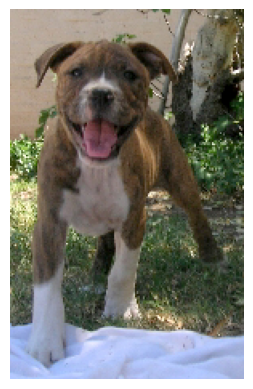

Image size (width, height): (146, 231)
Image shape (height, width, channels


In [16]:
import matplotlib.pyplot as plt
from PIL import Image
img_path = os.path.join(dog_src_dir, dog_files[500])
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()
print("Image size (width, height):", img.size)
import numpy as np
print("Image shape (height, width, channels")

In [17]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/Users/ponlawatchangto/Documents/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255) # ตั้งค่าไว้ก่อน ยังไม่

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory( train_dir, target_size=(150, 150), batch_size=20, class_mode='binary')

validation_generator = test_datagen.flow_from_directory( validation_dir, target_size=(150, 150), batch_size=20, class_mode='binary')

Found 1998 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [22]:
for data_batch, labels_batch in train_generator:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break   

data batch shape: (20, 150, 150, 3)
labels batch shape: (20,)


In [23]:
history = model.fit(train_generator,steps_per_epoch=100,epochs=30,validation_data=validation_generator,validation_steps=50)

Epoch 1/30
 31/100 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.5166 - loss: 0.7038

/Users/ponlawatchangto/Documents/Mylearning/4312/.venv/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.5360 - loss: 0.6921 - val_accuracy: 0.6020 - val_loss: 0.6808
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.5886 - loss: 0.6685 - val_accuracy: 0.5510 - val_loss: 0.6794
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.6171 - loss: 0.6491 - val_accuracy: 0.6230 - val_loss: 0.6518
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.6542 - loss: 0.6260 - val_accuracy: 0.6140 - val_loss: 0.6505
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.6772 - loss: 0.5996 - val_accuracy: 0.6240 - val_loss: 0.6436
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.7172 - loss: 0.5695 - val_accuracy: 0.6540 - val_loss: 0.6137
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.7357 - loss: 0.5439 - val_accuracy: 0.7020 - val_loss: 0.5848
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.7487 - loss: 0.5225 - val_accuracy: 0.713

In [24]:
model.save('cats_and_dogs_small_1.h5')

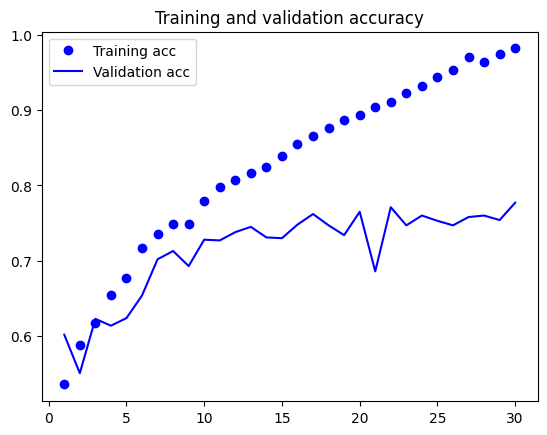

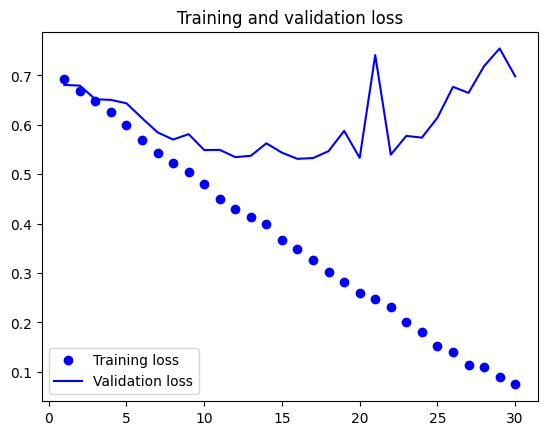

In [25]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']

val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')

plt.plot(epochs, val_acc, 'b', label='Validation acc')

plt.title('Training and validation accuracy')

plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')

plt.plot(epochs, val_loss, 'b', label='Validation loss')

plt.title('Training and validation loss')

plt.legend()

plt.show()